# Reading the EBA Pillar 3 Data Hub: source tables and how to merge them

**Purpose.** A self-contained account of how the public EBA Pillar 3 Data Hub is structured, which
objects a credit-risk analysis reads, and the joins that resolve an internal identifier into a
value attributable to a named institution.

**Worked example.** EU CR6 and EU CR6-A at 31 December 2025, merged to classify each banking
group's IRB exposure as advanced (AIRB) or foundation (FIRB) by asset class. The method
generalises: every Pillar 3 disclosure is read through the same join.

---

### Status and limitations

**This notebook is exploratory.** The Hub is a large model and our understanding of it remains
partial; the conventions documented here were established by inspection rather than from a
published specification. Errors are possible, and readers should treat the findings as provisional
and verify them independently before relying on them.

**The final chart reflects one set of choices among several defensible alternatives.** The
population definition, the treatment of the current-IRB signal, the mapping from open-table
members to asset classes, and the definition of AIRB/FIRB dominance each admit reasonable
variation, and different choices will move the result. Anyone using the output for a material
purpose should review every assumption in detail and satisfy themselves that it fits their
question.

**Execution.** All content is read live from the Hub, so the notebook requires network access and
takes approximately one minute to run. Row counts, table versions and the population reflect the
Hub as published at execution time rather than a fixed snapshot.

---

### How the model is read

1. The Hub is a single public **Power BI semantic model** arranged as a star schema.
2. A reported value is held in `fact_Value`, which carries internal identifiers alone.
3. Resolving that value into readable form requires joining **eight** entities: entity, instance,
   template, table, row, column, the fact, and the value measure.
4. An *open* table such as CR6 requires a ninth, `dm_TableKey`, which supplies the dimension
   member that the row and column coordinates leave unexpressed.
5. The join runs once per template, and the two results are merged on `LEI x asset class`.

## 1. What the Hub publishes

**One semantic model.** All content is obtained by querying it. Files such as CSV extracts are
artefacts produced by consumers of the model.

**Pillar 3 disclosure templates only.** These are coded `K_xx.xx` in the Data Point Model and
filed under disclosure modules (`CODIS`, `FINDIS`, `ESGDIS`, ...). COREP is supervisory reporting,
coded `C xx.xx`, and belongs to a separate framework held elsewhere. Certain disclosures cover
ground similar to COREP returns, and the identifiers, table versions and filed values that resolve
in this model are the disclosure ones throughout.

## 2. The connector

The Hub front-end is a public Power BI report. Reading it requires taking the temporary embed
token from the report page and POSTing a *semantic query* — a JSON description of entities,
selections and filters — to the query endpoint. The response is dictionary-encoded with a repeat
mask and a null mask, and decodes into ordinary rows.

The two cells below contain the connector. Subsequent cells use pandas alone.

In [1]:
import json
import time
import uuid

import pandas as pd
import requests

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

P3DH_URL = "https://edap-public.eba.europa.eu/Report/index/MTE1?rhversion=20260722160254-2"
P3DH_REPORT = "f0de0c7c-c532-4b55-9bef-da99423cf672"
P3DH_DB = "d9c4b646-c0e6-4b73-887f-8f6702855ae2"
P3DH_MODEL = 5131315
P3DH_HOST = "https://wabi-west-europe-d-primary-redirect.analysis.windows.net"
USER_AGENT = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
              "AppleWebKit/537.36 Chrome/127.0 Safari/537.36")

REFERENCE_DATE = "2025-12-31"


def get_token(attempts=5, pause=4.0):
    """The public embed token is inlined in the report page; gzip+base64 starts with 'H4sI'."""
    last = None
    for _ in range(attempts):
        try:
            session = requests.Session()
            session.headers["User-Agent"] = USER_AGENT
            page = session.get(P3DH_URL, allow_redirects=True, timeout=120)
            page.raise_for_status()
            start = page.text.find("H4sI")
            if start >= 0:
                return page.text[start:page.text.index('"', start)]
            last = f"no token in {len(page.text):,} bytes"
        except Exception as exc:
            last = repr(exc)
        time.sleep(pause)
    raise RuntimeError(f"could not obtain the public embed token: {last}")


TOKEN = get_token()
HEADERS = {"Authorization": f"EmbedToken {TOKEN}",
           "Content-Type": "application/json;charset=UTF-8",
           "X-PowerBI-ResourceKey": P3DH_REPORT}


def src(alias, entity):
    return {"Name": alias, "Entity": entity, "Type": 0}


def col(alias, prop):
    return {"Column": {"Expression": {"SourceRef": {"Source": alias}}, "Property": prop},
            "Name": f"{alias}.{prop}"}


def measure(alias, prop):
    return {"Measure": {"Expression": {"SourceRef": {"Source": alias}}, "Property": prop},
            "Name": f"{alias}.{prop}"}


def eq(alias, prop, literal):
    return {"Condition": {"Comparison": {
        "ComparisonKind": 0,
        "Left": {"Column": {"Expression": {"SourceRef": {"Source": alias}}, "Property": prop}},
        "Right": {"Literal": {"Value": literal}}}}}


print(f"embed token acquired ({len(TOKEN)} chars)")

embed token acquired (1885 chars)


In [2]:
def decode_rows(text):
    """Expand the Power BI dictionary / repeat-mask / null-mask encoding into plain rows."""
    payload = json.loads(text.lstrip("﻿"))
    shapes = payload["results"][0]["result"]["data"].get("dsr", {}).get("DataShapes")
    if shapes and "odata.error" in shapes[0]:
        raise RuntimeError(shapes[0]["odata.error"]["message"]["value"])

    decoded = []
    for result in payload["results"]:
        for data_set in result["result"]["data"].get("dsr", {}).get("DS", []):
            dicts, specs = data_set.get("ValueDicts", {}), None
            for phase in data_set.get("PH", []):
                for encoded_rows in phase.values():
                    previous = []
                    for encoded in encoded_rows:
                        specs = encoded.get("S", specs)
                        if specs is None:
                            continue
                        repeat = encoded.get("R", 0)
                        # the null-mask key is a non-ASCII glyph; accept either spelling
                        nulls = next((encoded[k] for k in ("Ø", "�") if k in encoded), 0)

                        def resolve(value, spec):
                            """Values arrive as indexes into a per-column dictionary."""
                            name = spec.get("DN")
                            if name in dicts and isinstance(value, int) \
                                    and 0 <= value < len(dicts[name]):
                                return dicts[name][value]
                            return value

                        def carried(pos):
                            return previous[pos] if pos < len(previous) else None

                        row = []
                        if "C" in encoded:            # compact form: one packed value list
                            values, taken = encoded["C"], 0
                            for pos, spec in enumerate(specs):
                                if nulls >> pos & 1:
                                    row.append(None)
                                elif repeat >> pos & 1 or taken >= len(values):
                                    row.append(carried(pos))
                                else:
                                    row.append(resolve(values[taken], spec))
                                    taken += 1
                        else:                          # verbose form: value per column name
                            for pos, spec in enumerate(specs):
                                key = spec.get("N", f"G{pos}")
                                if key in encoded:
                                    row.append(resolve(encoded[key], spec))
                                elif nulls >> pos & 1:
                                    row.append(None)
                                else:
                                    row.append(carried(pos))
                        decoded.append(row)
                        previous = row
    return decoded


def hub_query(sources, selections, filters=(), columns=None, limit=200_000):
    """Run one read-only semantic query and return a DataFrame."""
    body = {"version": "1.0.0", "queries": [{"Query": {"Commands": [{
        "SemanticQueryDataShapeCommand": {
            "Query": {"Version": 2, "From": list(sources),
                      "Select": list(selections), "Where": list(filters)},
            "Binding": {
                "Primary": {"Groupings": [{"Projections": list(range(len(selections)))}]},
                "DataReduction": {"DataVolume": 4, "Primary": {"Window": {"Count": limit}}},
                "Version": 1}}}],
        "QueryId": "",
        "ApplicationContext": {"DatasetId": P3DH_DB,
                               "Sources": [{"ReportId": P3DH_REPORT, "VisualId": "v"}]}}}],
        "cancelQueries": [], "modelId": P3DH_MODEL}
    headers = dict(HEADERS, ActivityId=str(uuid.uuid4()), RequestId=str(uuid.uuid4()))
    response = requests.post(f"{P3DH_HOST}/explore/querydata?synchronous=true",
                             headers=headers, json=body, timeout=300)
    response.raise_for_status()
    rows = decode_rows(response.content.decode("utf-8-sig"))
    return pd.DataFrame(rows, columns=columns or [s["Name"] for s in selections])

## 3. The entities in the model

The model's own schema is served by the `conceptualschema` endpoint — the same call the report
front-end makes on load. This is the full inventory.

In [3]:
schema = requests.post(
    f"{P3DH_HOST}/explore/conceptualschema",
    headers=dict(HEADERS, ActivityId=str(uuid.uuid4()), RequestId=str(uuid.uuid4())),
    json={"modelIds": [P3DH_MODEL], "userPreferredLocale": "en-US"},
    timeout=180,
).json()

entities = schema["schemas"][0]["schema"]["Entities"]
inventory = pd.DataFrame(
    [(e["Name"], len(e.get("Properties", []))) for e in entities],
    columns=["entity", "n_fields"],
).sort_values("entity", ignore_index=True)

print(f"{len(inventory)} entities in the public P3 Data Hub semantic model")
inventory

20 entities in the public P3 Data Hub semantic model


,entity,n_fields
0,DimDate,14
1,EDAP_Environment,3
2,FP_Pillar3,3
3,LastRefreshDate,1
4,Measure P3,28
5,Pages,1
6,dm_Cell,20
7,dm_Column,29
8,dm_Entity,29
9,dm_Module,12


## 4. What the tables that matter contain

Nine entities carry a credit-risk analysis. The rest are calendar, environment and report-page
helpers.

| Entity | What it holds | Fields used here |
|---|---|---|
| `fact_Value` | **The reported numbers.** One row per disclosed cell. Holds only identifiers plus three value families: `KeyValueRep`, `QualitValueRep`, `QuantValueRep`, and their `...Conv` currency-converted twins. | `InstanceID`, `TableVID`, `RowKey`, `ColumnKey`, `UniqueKeyID` |
| `Measure P3` | Power BI display measures over `fact_Value`. `FactValue` is the rendered value — convenient, but display logic. | `FactValue` |
| `dm_Entity` | **Who reported.** Versioned institution master data: one institution occupies several rows. | `ENT_NAM`, `EntityCode` (LEI), `Country`, `InstitutionType`, `IS_HIG_LEV_EEA`, `EntityKey` |
| `dm_ReportInstance` | **Which submission.** One row per entity x module x reference date x submission, including resubmissions. | `InstanceID`, `ReferenceDate`, `IsCurrent`, `IsAccepted`, `Status`, `Report File Link` |
| `dm_Template` | The regulatory template: `K_26.00` = EU CR6, `K_26.01` = EU CR6-A. May be abstract. | `TemplateCode` |
| `dm_Table` | The **physical, versioned** table a template resolves to. `K_26.00` is abstract and resolves to `K_26.00.a` and `K_26.00.b`. | `TableVID`, `TableCode` |
| `dm_Row` | Row headers *for one `TableVID`*: `HeaderCode` (`0010`, `0180`, ...) and `HeaderLabel`. | `HeaderCode`, `HeaderLabel` |
| `dm_Column` | Column headers for one `TableVID`, same shape as `dm_Row`. | `HeaderCode`, `HeaderLabel` |
| `dm_TableKey` | **Open-table members.** Where an axis is open, the dimension member is held here and addressed by `UniqueKeyID`. | `UniqueKeyID`, `KeyDescriptor`, `SheetKey1` |

Also relevant: `dm_Sheet` (the third axis, used by templates that carry sheets), `dm_Cell` (the
row x column x sheet cell definitions, including `IsShaded` for cells marked inapplicable by
design), `dm_Variable` (the DPM metric and data type behind a cell), `dm_ReportTable` (whether a
table was filed, which separates "not reported" from "reported zero"), and `dm_Module` (the
disclosure module a template belongs to).

## 5. How they merge

The model is a star around `fact_Value`. Reading a single number means walking outwards on every
axis at once:

```mermaid
flowchart LR
    E["dm_Entity<br/>LEI, name, country"] -->|EntityKey| I["dm_ReportInstance<br/>date, IsCurrent, IsAccepted"]
    I -->|InstanceID| F["fact_Value<br/>the reported number"]
    TP["dm_Template<br/>K_26.00 / K_26.01"] -->|TemplateID| T["dm_Table<br/>TableVID, TableCode"]
    T -->|TableVID| R["dm_Row<br/>HeaderCode"]
    T -->|TableVID| C["dm_Column<br/>HeaderCode"]
    T -->|TableVID| TK["dm_TableKey<br/>open member"]
    R -->|RowKey| F
    C -->|ColumnKey| F
    TK -->|UniqueKeyID| F
    F --> V["Measure P3.FactValue<br/>rendered value"]
```

The join keys, in the direction the query uses them:

| From | To | Key | Why it is needed |
|---|---|---|---|
| `dm_Entity` | `dm_ReportInstance` | `EntityKey` | Pins the *entity version* that filed, not just the LEI |
| `dm_ReportInstance` | `fact_Value` | `InstanceID` | Ties the number to one submission |
| `dm_Template` | `dm_Table` | `TemplateID` | Abstract template to physical table |
| `dm_Table` | `dm_Row` / `dm_Column` / `dm_Sheet` | `TableVID` | Header codes only mean something *inside* a `TableVID` |
| `dm_Row` / `dm_Column` | `fact_Value` | `RowKey` / `ColumnKey` | Gives the fact its `0180` / `0040` coordinates |
| `dm_TableKey` | `fact_Value` | `TableVID` + `UniqueKeyID` | Supplies the open-table member |

The semantic query expresses these implicitly. Listing the entities in `From` and selecting
columns from each leaves the engine to resolve the model relationships, which is why the
extraction code below takes the form of a flat list of aliases.

In [4]:
# The eight-entity join, plus dm_TableKey for the open table.
FACT_SOURCES = [src(a, e) for a, e in [
    ("e", "dm_Entity"), ("t", "dm_Template"), ("i", "dm_ReportInstance"), ("tb", "dm_Table"),
    ("r", "dm_Row"), ("c", "dm_Column"), ("f", "fact_Value"), ("v", "Measure P3"),
]]

FACT_SELECT = [
    col("e", "ENT_NAM"), col("e", "EntityCode"), col("e", "InstitutionType"),
    col("e", "Country"), col("e", "IS_HIG_LEV_EEA"), col("i", "InstanceID"),
    col("i", "ReferenceDate"), col("i", "IsCurrent"), col("i", "IsAccepted"),
    col("i", "Status"), col("i", "Report File Link"), col("tb", "TableVID"),
    col("tb", "TableCode"), col("r", "HeaderCode"), col("c", "HeaderCode"),
]
FACT_COLUMNS = ["bank", "lei", "institution_type", "country", "is_highest_eea", "instance_id",
                "reference_date", "is_current", "is_accepted", "status", "source_link",
                "table_vid", "table_code", "row_code", "column_code"]

# Date plus IsCurrent is the minimum instance filter; the rest is applied after extraction.
CURRENT_AT_DATE = [
    eq("i", "ReferenceDate", f"datetime'{REFERENCE_DATE}T00:00:00'"),
    eq("i", "IsCurrent", "1L"),
]

pd.DataFrame(
    [
        ("e",  "dm_Entity",         "LEI, name, country, institution type", "EntityKey -> dm_ReportInstance"),
        ("i",  "dm_ReportInstance", "date, IsCurrent, IsAccepted, source link", "InstanceID -> fact_Value"),
        ("t",  "dm_Template",       "TemplateCode filter",                  "TemplateID -> dm_Table"),
        ("tb", "dm_Table",          "TableVID, TableCode",                  "TableVID -> rows/columns/keys"),
        ("r",  "dm_Row",            "row HeaderCode",                       "RowKey -> fact_Value"),
        ("c",  "dm_Column",         "column HeaderCode",                    "ColumnKey -> fact_Value"),
        ("f",  "fact_Value",        "the fact + UniqueKeyID",               "the grain"),
        ("v",  "Measure P3",        "FactValue (rendered)",                 "measure over fact_Value"),
        ("k",  "dm_TableKey",       "KeyDescriptor, SheetKey1 (open tables)", "UniqueKeyID -> fact_Value"),
    ],
    columns=["alias", "entity", "contributes", "joins by"],
)

,alias,entity,contributes,joins by
0,e,dm_Entity,"LEI, name, country, institution type",EntityKey -> dm_ReportInstance
1,i,dm_ReportInstance,"date, IsCurrent, IsAccepted, source link",InstanceID -> fact_Value
2,t,dm_Template,TemplateCode filter,TemplateID -> dm_Table
3,tb,dm_Table,"TableVID, TableCode",TableVID -> rows/columns/keys
4,r,dm_Row,row HeaderCode,RowKey -> fact_Value
5,c,dm_Column,column HeaderCode,ColumnKey -> fact_Value
6,f,fact_Value,the fact + UniqueKeyID,the grain
7,v,Measure P3,FactValue (rendered),measure over fact_Value
8,k,dm_TableKey,"KeyDescriptor, SheetKey1 (open tables)",UniqueKeyID -> fact_Value


## 6. Resolve the table version from the data

`TableVID` identifies a *physical table version*, and a single template code accumulates several
as the framework evolves. The same table also carries different identifiers in the Hub and in the
published DPM database. Filtering by `TemplateCode` and allowing the date and `IsCurrent`
conditions to select the version that carries facts therefore remains correct across framework
releases and across systems.

In [5]:
versions = hub_query(
    [src("t", "dm_Template"), src("tb", "dm_Table")],
    [col("t", "TemplateCode"), col("t", "TemplateName"),
     col("tb", "TableVID"), col("tb", "TableCode")],
    columns=["template_code", "template_name", "table_vid", "table_code"],
)

print(f"templates in the model : {versions['template_code'].nunique()}")
print(f"physical table codes   : {versions['table_code'].nunique()}")
print(f"table versions         : {versions['table_vid'].nunique()}")
print()
print("Every version of the two templates used here:")
versions[versions["template_code"].isin(["K_26.00", "K_26.01"])].sort_values(
    ["template_code", "table_code", "table_vid"]
)[["template_code", "table_code", "table_vid"]]

templates in the model : 117
physical table codes   : 195
table versions         : 415

Every version of the two templates used here:


,template_code,table_code,table_vid
140,K_26.00,K_26.00.a,2328
143,K_26.00,K_26.00.a,6295
144,K_26.00,K_26.00.a,6699
141,K_26.00,K_26.00.b,2407
142,K_26.00,K_26.00.b,6294
145,K_26.00,K_26.00.b,6703
146,K_26.01,K_26.01,2329
147,K_26.01,K_26.01,6261
148,K_26.01,K_26.01,6713


## 7. The two extracts

Two tightly filtered queries.

| Extract | Filter | Grain |
|---|---|---|
| **CR6-A** | `TemplateCode = K_26.01`, the reference date, `IsCurrent = 1` | LEI x row code x column code |
| **CR6** | `TemplateCode = K_26.00`, same date and current filter, **plus** row `0180` and column `0040` | LEI x `UniqueKeyID` (the open member) |

CR6-A is a fixed table, so its rows *are* the asset classes. CR6 is an open table: every fact sits
at the same coordinate `r0180 x c0040`, and the asset class is held in the member.

In [6]:
cr6a = hub_query(
    FACT_SOURCES,
    FACT_SELECT + [measure("v", "FactValue")],
    [eq("t", "TemplateCode", "'K_26.01'")] + CURRENT_AT_DATE,
    columns=FACT_COLUMNS + ["fact_value"],
)

cr6 = hub_query(
    FACT_SOURCES + [src("k", "dm_TableKey")],
    FACT_SELECT + [col("f", "UniqueKeyID"), col("k", "KeyDescriptor"),
                   col("k", "SheetKey1"), measure("v", "FactValue")],
    [eq("t", "TemplateCode", "'K_26.00'")] + CURRENT_AT_DATE
    + [eq("r", "HeaderCode", "'0180'"), eq("c", "HeaderCode", "'0040'")],
    columns=FACT_COLUMNS + ["unique_key_id", "key_descriptor", "member", "fact_value"],
)

print(f"CR6-A : {len(cr6a):>5} facts, {cr6a['lei'].nunique()} LEIs, "
      f"TableVID {sorted(cr6a['table_vid'].unique())}, columns {sorted(cr6a['column_code'].unique())}")
print(f"CR6   : {len(cr6):>5} facts, {cr6['lei'].nunique()} LEIs, "
      f"TableVID {sorted(cr6['table_vid'].unique())}")
print()
print("The date and IsCurrent filter selected the table version on its own - nothing hardcoded.")

cr6a[["bank", "lei", "table_code", "row_code", "column_code", "fact_value"]].head(4)

CR6-A :  5398 facts, 94 LEIs, TableVID [np.int64(6261)], columns ['0010', '0020', '0030', '0040', '0050']
CR6   :   680 facts, 93 LEIs, TableVID [np.int64(6295)]

The date and IsCurrent filter selected the table version on its own - nothing hardcoded.


,bank,lei,table_code,row_code,column_code,fact_value
0,ABN AMRO Bank N.V.,BFXS5XCH7N0Y05NIXW11,K_26.01,0010,0020,87110150499.4045D
1,ABN AMRO Bank N.V.,BFXS5XCH7N0Y05NIXW11,K_26.01,0010,0030,1D
2,ABN AMRO Bank N.V.,BFXS5XCH7N0Y05NIXW11,K_26.01,0020,0020,2919115426.281D
3,ABN AMRO Bank N.V.,BFXS5XCH7N0Y05NIXW11,K_26.01,0020,0030,1D


`Measure P3.FactValue` is display logic: it returns a string with a trailing `D` and requires
parsing before use. `ReferenceDate` arrives as epoch milliseconds.

In [7]:
# Every CR6 fact sits at r0180 x c0040; the member carries the meaning.
cr6[["bank", "row_code", "column_code", "unique_key_id", "member", "fact_value"]].head(4)

,bank,row_code,column_code,unique_key_id,member,fact_value
0,ABN AMRO Bank N.V.,0180,0040,1122946479518752379,Retail exposures - Other - with own estimates of LGD or conversion factors,28807114.59D
1,ABN AMRO Bank N.V.,0180,0040,161333573377302602,None,391006880.14D
2,ABN AMRO Bank N.V.,0180,0040,2427654596990224407,Institutions without own estimates of LGD or conversion factors,6659568572.67D
3,ABN AMRO Bank N.V.,0180,0040,4560943881806930161,Retail exposures - Secured by residential real estate - with own estimates of LGD or c...,142655064832.01D


## 8. Merge step A — resolve the open-table member

CR6 facts carry `UniqueKeyID`, and `dm_TableKey` resolves it into text. Since all CR6 facts share
the same row and column coordinates, this join supplies the whole of the distinction between them.
The member text appears twice: in `KeyDescriptor` ("Exposure class by approach ... = X") and in
`SheetKey1` ("X" alone), making `SheetKey1` the field to use.

In [8]:
members = (
    cr6.groupby("unique_key_id", dropna=False)
    .agg(member=("member", "first"), facts=("fact_value", "size"))
    .sort_values("facts", ascending=False)
)
print(f"{len(members)} distinct open-table keys across {len(cr6)} CR6 facts")
print(f"unresolved: {members['member'].isna().sum()} key(s), "
      f"{members.loc[members['member'].isna(), 'facts'].sum()} facts")
members

18 distinct open-table keys across 680 CR6 facts
unresolved: 1 key(s), 81 facts


,member,facts
unique_key_id,,
161333573377302602,None,81
4560943881806930161,Retail exposures - Secured by residential real estate - with own estimates of LGD or c...,79
1122946479518752379,Retail exposures - Other - with own estimates of LGD or conversion factors,77
2427654596990224407,Institutions without own estimates of LGD or conversion factors,56
-5509903175489245444,Corporates - Other with own estimates of LGD or conversion factors,53
-3278835995078863793,Retail - Qualifying revolving - with own estimates of LGD or conversion factors,42
-471797941023451819,Corporates - Specialised Lending without own estimates of LGD or conversion factors,35
-4774017368890521574,Corporates - Purchased receivables without own estimates of LGD or conversion factors,33
-2730708368837090091,Corporates - Specialised Lending with own estimates of LGD or conversion factors,32


A key that fails to resolve through the implicit join may still be present in `dm_TableKey` under
a different rendering of the same 64-bit identifier. Querying the key table directly allows the
two sides to be compared: where each side holds the same number of members and exactly one
unmatched value, the unmatched pair denotes one member, and it is recoverable by elimination.
The check below reports the comparison so that the inference remains visible and falsifiable.

In [9]:
table_keys = hub_query(
    [src("k", "dm_TableKey")],
    [col("k", "TableVID"), col("k", "UniqueKeyID"),
     col("k", "KeyDescriptor"), col("k", "SheetKey1")],
    [eq("k", "TableVID", f"'{cr6['table_vid'].iloc[0]}'")],
    columns=["table_vid", "unique_key_id", "key_descriptor", "member"],
)

fact_ids = set(cr6["unique_key_id"].astype(str))
key_ids = set(table_keys["unique_key_id"].astype(str))
orphan_fact, orphan_key = sorted(fact_ids - key_ids), sorted(key_ids - fact_ids)

print(f"members in dm_TableKey : {len(key_ids)}")
print(f"keys used by the facts : {len(fact_ids)}")
print(f"unmatched fact key     : {orphan_fact}")
print(f"unmatched dm_TableKey  : {orphan_key}")

if len(orphan_fact) == 1 and len(orphan_key) == 1:
    recovered = table_keys.loc[table_keys["unique_key_id"].astype(str) == orphan_key[0],
                               "member"].iloc[0]
    cr6["member"] = cr6["member"].fillna(
        cr6["unique_key_id"].astype(str).map({orphan_fact[0]: recovered})
    )
    print(f"\nrecovered by elimination: {orphan_fact[0]} -> {recovered}")

print(f"still unresolved: {int(cr6['member'].isna().sum())}")

members in dm_TableKey : 18
keys used by the facts : 18
unmatched fact key     : ['161333573377302602']
unmatched dm_TableKey  : ['-1161333573377302602']

recovered by elimination: 161333573377302602 -> Corporates - Other without own estimates of LGD or conversion factors
still unresolved: 0


## 9. Merge step B — select the instance and the entity

Instance and entity selection belongs to the merge itself. `dm_ReportInstance` retains
resubmissions and `dm_Entity` retains every entity version, so these conditions determine both the
bank count and which value is read.

A superseded filing retains accepted status, so `IsCurrent` is required alongside `IsAccepted`.
The comparison below takes the CR6-A total row and total-exposure column for **all** instances at
the reference date and contrasts the current against the superseded value for banks holding both.

In [10]:
resubmissions = hub_query(
    FACT_SOURCES,
    [col("e", "ENT_NAM"), col("e", "EntityCode"), col("i", "IsCurrent"),
     col("i", "IsAccepted"), col("i", "Status"), measure("v", "FactValue")],
    [eq("t", "TemplateCode", "'K_26.01'"),
     eq("i", "ReferenceDate", f"datetime'{REFERENCE_DATE}T00:00:00'"),
     eq("r", "HeaderCode", "'0160'"), eq("c", "HeaderCode", "'0020'")],
    columns=["bank", "lei", "is_current", "is_accepted", "status", "fact_value"],
)
resubmissions["value"] = pd.to_numeric(
    resubmissions["fact_value"].astype(str).str.rstrip("D"), errors="coerce")

accepted = resubmissions[(pd.to_numeric(resubmissions["is_accepted"]) == 1)
                         & (resubmissions["status"] == "Accepted")]
paired = (
    accepted.pivot_table(index=["bank", "lei"], columns="is_current",
                         values="value", aggfunc="max")
    .rename(columns={0: "superseded", 1: "current"})
    .dropna()
)
paired["current / superseded"] = (paired["current"] / paired["superseded"]).round(3)

print(f"accepted total-exposure facts at the reference date : {len(accepted)}")
print(f"banks holding both a current and a superseded value : {len(paired)}")
print(f"of those, values that differ                        : "
      f"{(paired['current / superseded'] != 1).sum()}")
paired.sort_values("current / superseded").head(8)

accepted total-exposure facts at the reference date : 109
banks holding both a current and a superseded value : 16
of those, values that differ                        : 3


,is_current,superseded,current,current / superseded
bank,lei,,,
Skandinaviska Enskilda Banken - gruppen,F3JS33DEI6XQ4ZBPTN86,3.171539e+12,2.930776e+11,0.092
"Banco de Sabadell, S.A.",SI5RG2M0WQQLZCXKRM20,2.296830e+12,2.296830e+11,0.100
Aktiebolaget Svensk Exportkredit,1FOLRR5RWTWWI397R131,3.946585e+10,3.946585e+10,1.000
ABN AMRO Bank N.V.,BFXS5XCH7N0Y05NIXW11,3.933463e+11,3.933463e+11,1.000
Banka Intesa Sanpaolo d.d.,549300ECJDDLOVWWL932,4.764182e+06,4.764182e+06,1.000
COMMERZBANK Aktiengesellschaft,851WYGNLUQLFZBSYGB56,4.769878e+11,4.769878e+11,1.000
Coöperatieve Rabobank U.A.,DG3RU1DBUFHT4ZF9WN62,5.403425e+11,5.403425e+11,1.000
BNP Paribas,R0MUWSFPU8MPRO8K5P83,2.013726e+12,2.013726e+12,1.000


The differing rows establish why `IsCurrent = 1` is required: the superseded figure is accepted,
carries the same reference date, and departs from the current value by orders of magnitude.

The full selection rule applied from here on:

```text
ReferenceDate = 2025-12-31
AND IsCurrent = 1  AND IsAccepted  AND Status = 'Accepted'
AND InstitutionType IN ('Large highest EEA', 'Other highest EEA')
AND IS_HIG_LEV_EEA = 'YES'
AND CR6-A total row 0160 x column 0020 > 0
```

The final condition restricts the population to groups reporting exposure. The institution-type
conditions restrict it to highest-level EEA consolidated groups, so each group appears once.

In [11]:
def typed(df):
    out = df.copy()
    out["value"] = pd.to_numeric(out["fact_value"].astype(str).str.rstrip("D"), errors="coerce")
    out["ref_date"] = pd.to_datetime(pd.to_numeric(out["reference_date"]), unit="ms")
    return out


def current_group_facts(df):
    df = typed(df)
    return df[
        (df["ref_date"] == REFERENCE_DATE)
        & (pd.to_numeric(df["is_current"]) == 1)
        & (pd.to_numeric(df["is_accepted"]) == 1)
        & (df["status"] == "Accepted")
        & (df["institution_type"].isin(["Large highest EEA", "Other highest EEA"]))
        & (df["is_highest_eea"].str.upper() == "YES")
    ]


cr6a_f, cr6_f = current_group_facts(cr6a), current_group_facts(cr6)

total_ead = (
    cr6a_f[(cr6a_f["row_code"] == "0160") & (cr6a_f["column_code"] == "0020")]
    .groupby("lei")["value"].max()
)
population = total_ead[total_ead > 0].index

print(f"LEIs in the raw CR6-A extract          : {cr6a['lei'].nunique()}")
print(f"after current / accepted / highest-EEA : {cr6a_f['lei'].nunique()}")
print(f"after positive total EAD (row 0160)    : {len(population)}   <- the population")

LEIs in the raw CR6-A extract          : 94
after current / accepted / highest-EEA : 78
after positive total EAD (row 0160)    : 77   <- the population


### 9.1 Two properties of the values that constrain what can be computed

Column `0040` is the current-IRB share. Institutions report it on two different scales — as a
ratio and as percentage points — so it is used below as a positive / non-positive signal alone.
Treating it as a numeric percentage would require establishing the convention per institution.

Reported total exposure spans a range wider than institution size explains, which suggests that
reporting units differ between filers. Cross-bank monetary aggregation therefore requires
validating magnitudes against source filings first, and this notebook confines itself to counts.

In [12]:
pct = cr6a_f.loc[cr6a_f["column_code"] == "0040", "value"].dropna()
print("CR6-A column 0040 - reported scale")
print(f"  facts                               : {len(pct)}")
print(f"  reported as a ratio (<= 1)          : {(pct <= 1).sum():>5}   max {pct[pct <= 1].max():.4f}")
print(f"  reported as percentage points (> 1) : {(pct > 1).sum():>5}   max {pct[pct > 1].max():.4f}")

reported = total_ead[total_ead > 0].sort_values()
print("\nCR6-A total exposure (row 0160 x column 0020) across the population")
print(f"  smallest : {reported.iloc[0]:>20,.0f}")
print(f"  largest  : {reported.iloc[-1]:>20,.0f}")
print(f"  ratio    : {reported.iloc[-1] / reported.iloc[0]:>20,.0f}x")

CR6-A column 0040 - reported scale
  facts                               : 862
  reported as a ratio (<= 1)          :   835   max 1.0000
  reported as percentage points (> 1) :    27   max 100.0000

CR6-A total exposure (row 0160 x column 0020) across the population
  smallest :               29,478
  largest  :    2,013,726,065,579
  ratio    :           68,312,607x


## 10. Merge step C — join the two templates on `LEI x asset class`

The two templates express the asset class differently:

* CR6-A gives it as a **row code** (`0040` = Institutions, `0135` = Other retail, ...).
* CR6 holds it inside the **member text**, combined with the AIRB/FIRB distinction.

Each side is therefore mapped to a common asset-class label before joining. The member text also
supplies the AIRB/FIRB classification: "with own estimates of LGD" denotes AIRB, "without own
estimates" denotes FIRB.

The mapping below is a keyword match against member text. It is one of the assumptions most worth
reviewing: the member wording is a reporting convention, and a change to it would silently alter
the mapping.

In [13]:
# CR6-A side: row code -> asset class, keeping the two columns the analysis uses.
CR6A_ROWS = {
    "0010": "Central governments and central banks",
    "0020": "Regional governments and local authorities",
    "0030": "Public-sector entities",
    "0040": "Institutions",
    "0051": "Corporates - general",
    "0052": "Corporates - specialised lending",
    "0075": "Corporates - purchased receivables",
    "0110": "Retail - qualifying revolving",
    "0120": "Retail - residential real estate",
    "0130": "Retail - purchased receivables",
    "0135": "Retail - other",
    "0140": "Equity",
    "0145": "Collective investment undertakings",
    "0150": "Other non-credit-obligation assets",
}

cr6a_side = cr6a_f[cr6a_f["lei"].isin(population)
                   & cr6a_f["column_code"].isin(["0020", "0040"])].copy()
cr6a_side["asset_class"] = cr6a_side["row_code"].map(CR6A_ROWS)
cr6a_side = (
    cr6a_side.dropna(subset=["asset_class"])
    .pivot_table(index=["lei", "asset_class"], columns="column_code", values="value", aggfunc="max")
    .rename(columns={"0020": "cr6a_class_ead", "0040": "cr6a_irb_signal"})
    .rename_axis(None, axis=1)
    .reset_index()
)
cr6a_side.head(4)

,lei,asset_class,cr6a_class_ead,cr6a_irb_signal
0,0W2PZJM8XOY22M4GG883,Central governments and central banks,1.364499e+10,0.028501
1,0W2PZJM8XOY22M4GG883,Corporates - general,1.847867e+10,1.000000
2,0W2PZJM8XOY22M4GG883,Corporates - purchased receivables,4.688619e+08,1.000000
3,0W2PZJM8XOY22M4GG883,Corporates - specialised lending,1.006634e+10,1.000000


In [14]:
# CR6 side: member text -> asset class + IRB variant.
MEMBER_TO_CLASS = [
    ("central governments", "Central governments and central banks"),
    ("regional governments", "Regional governments and local authorities"),
    ("public sector entities", "Public-sector entities"),
    ("institutions", "Institutions"),
    ("corporates - purchased receivables", "Corporates - purchased receivables"),
    ("corporates - specialised lending", "Corporates - specialised lending"),
    ("corporates - other", "Corporates - general"),
    ("retail - qualifying revolving", "Retail - qualifying revolving"),
    ("retail exposures - secured by residential", "Retail - residential real estate"),
    ("retail exposures - purchased receivables", "Retail - purchased receivables"),
    ("retail exposures - other", "Retail - other"),
    ("collective investment undertakings", "Collective investment undertakings"),
]


def member_class(member):
    low = str(member).lower()
    for needle, label in MEMBER_TO_CLASS:
        if needle in low:
            return label
    return None


def member_variant(member):
    low = str(member).lower()
    if "without own estimates" in low:
        return "FIRB"
    if "with own estimates" in low:
        return "AIRB"
    return "IRB - not specified"


cr6_side = cr6_f[cr6_f["lei"].isin(population)].copy()
cr6_side["asset_class"] = cr6_side["member"].map(member_class)
cr6_side["irb_variant"] = cr6_side["member"].map(member_variant)

cr6_side = (
    cr6_side.dropna(subset=["asset_class"])
    .assign(value=lambda d: d["value"].clip(lower=0))
    .pivot_table(index=["lei", "asset_class"], columns="irb_variant", values="value", aggfunc="sum")
    .rename(columns={"AIRB": "airb_ead", "FIRB": "firb_ead", "IRB - not specified": "other_irb_ead"})
    .rename_axis(None, axis=1)
    .reset_index()
)
cr6_side.head(4)

,lei,asset_class,airb_ead,firb_ead,other_irb_ead
0,0W2PZJM8XOY22M4GG883,Central governments and central banks,NaN,6.046445e+07,NaN
1,0W2PZJM8XOY22M4GG883,Corporates - general,NaN,1.104803e+10,NaN
2,0W2PZJM8XOY22M4GG883,Corporates - purchased receivables,NaN,3.250422e+08,NaN
3,0W2PZJM8XOY22M4GG883,Corporates - specialised lending,NaN,9.724105e+09,NaN


**Anchor the join on a full grid.** A `LEI x asset class` grid built first, with both templates
joined onto it, retains all evidence from either side and records "not reported" as an explicit
state. Anchoring on a single template limits the result to what that template carries: a CR6-A
anchor covers only the bank-class pairs present in CR6-A filings, and a CR6 anchor covers only
those with IRB exposure. The count below measures the first case.

In [15]:
ASSET_CLASSES = list(dict.fromkeys(CR6A_ROWS.values()))
EAD_COLS = ["airb_ead", "firb_ead", "other_irb_ead"]

grid = pd.MultiIndex.from_product(
    [sorted(population), ASSET_CLASSES], names=["lei", "asset_class"]
).to_frame(index=False)

merged = (
    grid.merge(cr6a_side, on=["lei", "asset_class"], how="left")
        .merge(cr6_side, on=["lei", "asset_class"], how="left")
)
merged[EAD_COLS] = merged[EAD_COLS].fillna(0.0)
merged = merged.join(cr6a_f.groupby("lei")[["bank", "country"]].first(), on="lei")

# How much a template-anchored join would lose, measured directly.
unmatched = cr6_side.merge(cr6a_side[["lei", "asset_class"]], on=["lei", "asset_class"],
                           how="left", indicator=True)
print(f"grid : {len(merged)} rows ({len(population)} banks x {len(ASSET_CLASSES)} classes)")
print(f"CR6 rows with no matching CR6-A row, which a CR6-A-anchored join would drop: "
      f"{(unmatched['_merge'] == 'left_only').sum()} of {len(cr6_side)}")

merged.loc[merged["bank"] == "ABN AMRO Bank N.V.",
           ["bank", "asset_class", "cr6a_class_ead", "cr6a_irb_signal", "airb_ead", "firb_ead"]]

grid : 1078 rows (77 banks x 14 classes)
CR6 rows with no matching CR6-A row, which a CR6-A-anchored join would drop: 18 of 414


,bank,asset_class,cr6a_class_ead,cr6a_irb_signal,airb_ead,firb_ead
728,ABN AMRO Bank N.V.,Central governments and central banks,8.711015e+10,NaN,0.000000e+00,0.000000e+00
729,ABN AMRO Bank N.V.,Regional governments and local authorities,2.919115e+09,NaN,0.000000e+00,0.000000e+00
730,ABN AMRO Bank N.V.,Public-sector entities,3.559780e+09,NaN,0.000000e+00,0.000000e+00
731,ABN AMRO Bank N.V.,Institutions,1.166529e+10,0.7987,0.000000e+00,6.659569e+09
732,ABN AMRO Bank N.V.,Corporates - general,6.992290e+10,0.0056,0.000000e+00,3.910069e+08
733,ABN AMRO Bank N.V.,Corporates - specialised lending,1.283298e+10,NaN,0.000000e+00,0.000000e+00
734,ABN AMRO Bank N.V.,Corporates - purchased receivables,NaN,NaN,0.000000e+00,0.000000e+00
735,ABN AMRO Bank N.V.,Retail - qualifying revolving,NaN,NaN,0.000000e+00,0.000000e+00
736,ABN AMRO Bank N.V.,Retail - residential real estate,1.734704e+11,0.9635,1.426551e+11,0.000000e+00
737,ABN AMRO Bank N.V.,Retail - purchased receivables,NaN,NaN,0.000000e+00,0.000000e+00


In [16]:
# Where each side carries a signal, before any classification rule is applied.
pd.DataFrame({
    "cells": [
        (merged["cr6a_class_ead"] > 0).sum(),
        (merged["cr6a_irb_signal"].fillna(0) > 0).sum(),
        (merged["airb_ead"] > 0).sum(),
        (merged["firb_ead"] > 0).sum(),
        ((merged["airb_ead"] > 0) & (merged["firb_ead"] > 0)).sum(),
    ]},
    index=["CR6-A reports exposure (c0020 > 0)", "CR6-A reports current IRB (c0040 > 0)",
           "CR6 has AIRB EAD", "CR6 has FIRB EAD", "both AIRB and FIRB"],
)

,cells
CR6-A reports exposure (c0020 > 0),794
CR6-A reports current IRB (c0040 > 0),369
CR6 has AIRB EAD,248
CR6 has FIRB EAD,176
both AIRB and FIRB,67


## 11. What these tables hold

Sections 1-10 cover *structure*. This section covers *content*: which measures exist, in which
column, in what unit.

`dm_Row` and `dm_Column` supply a code and a label. The **metric** behind a column — whether it
holds EAD, RWEA, PD or a provision — comes from `dm_Variable`, reached through `dm_Cell`, which
defines the row x column x sheet cells of a table version and points each at a `VariableID`.
`dm_Variable.MainProperty` is the DPM metric and `DataType` its unit.

In [17]:
def table_layout(table_vid):
    """Row and column headers, plus the DPM metric and data type behind each column."""
    axis = {}
    for alias, entity, name in [("r", "dm_Row", "row"), ("c", "dm_Column", "column")]:
        axis[name] = hub_query(
            [src(alias, entity)],
            [col(alias, "HeaderCode"), col(alias, "HeaderLabel"), col(alias, "Order")],
            [eq(alias, "TableVID", f"'{table_vid}'")],
            columns=["code", "label", "order"],
        ).sort_values("order", ignore_index=True)

    metrics = hub_query(
        [src("cl", "dm_Cell"), src("c", "dm_Column"), src("v", "dm_Variable")],
        [col("c", "HeaderCode"), col("v", "MainProperty"), col("v", "DataType")],
        [eq("cl", "TableVID", f"'{table_vid}'")],
        columns=["code", "metric", "unit"],
    ).drop_duplicates("code")

    axis["column"] = axis["column"].merge(metrics, on="code", how="left")
    return axis


CR6_VID = int(cr6["table_vid"].iloc[0])
CR6A_VID = int(cr6a["table_vid"].iloc[0])

# The totals table of the same abstract template, resolved the same way: ask which version
# carries current facts at the reference date rather than picking a number.
CR6B_VID = int(hub_query(
    FACT_SOURCES,
    [col("tb", "TableVID"), col("tb", "TableCode"), measure("v", "FactValue")],
    [eq("t", "TemplateCode", "'K_26.00'")] + CURRENT_AT_DATE
    + [eq("r", "HeaderCode", "'0190'"), eq("c", "HeaderCode", "'0040'")],
    columns=["table_vid", "table_code", "fact_value"],
)["table_vid"].iloc[0])

cr6_layout, cr6a_layout, cr6b_layout = (table_layout(v) for v in (CR6_VID, CR6A_VID, CR6B_VID))
for label, vid, layout in [("K_26.00.a", CR6_VID, cr6_layout),
                           ("K_26.00.b", CR6B_VID, cr6b_layout),
                           ("K_26.01", CR6A_VID, cr6a_layout)]:
    print(f"{label:<10} TableVID {vid}: "
          f"{len(layout['row']):>2} rows x {len(layout['column']):>2} columns")

K_26.00.a  TableVID 6295: 18 rows x 12 columns
K_26.00.b  TableVID 6294:  1 rows x 10 columns
K_26.01    TableVID 6261: 19 rows x  5 columns


### 11.1 EU CR6 — the IRB risk-parameter table

The richest credit-risk table in the model, covering exposure, the IRB risk parameters and the
capital outcome.

In [18]:
cr6_layout["column"][["code", "label", "metric", "unit"]]

,code,label,metric,unit
0,0010,a. On-balance sheet exposures,Exposure value,monetary
1,0020,b. Off-balance-sheet exposures pre-conversion factors,Exposure value,monetary
2,0030,c. Exposure weighted average conversion factors,Credit conversion factor,percentage
3,0040,d. Exposure value post conversion factors and post CRM,Exposure value,monetary
4,0050,e. Exposure weighted average PD (%),Probability of default,percentage
5,0060,f. Number of obligors,Number of obligors,integer
6,0070,g. Exposure weighted average LGD (%),Loss Given Default,percentage
7,0080,h. Exposure weighted average maturity (years),Maturity value (years decimal),decimal
8,0090,i. Risk weighted exposure amount after supporting factors,Risk weighted exposure amount,monetary
9,0100,j. Density of risk weighted exposure amounts,Density of risk weighted exposure amounts,percentage


Read as a list, EU CR6 gives, per exposure class x PD band:

* **Exposure** — on-balance-sheet (`0010`), off-balance-sheet pre-CCF (`0020`), and **EAD** post
  conversion factor and post CRM (`0040`). `0040` is the one used in this notebook.
* **Risk parameters** — average **CCF** (`0030`), average **PD** (`0050`), average **LGD**
  (`0070`), average **maturity** in years (`0080`), and **number of obligors** (`0060`).
* **Capital outcome** — **RWEA** after supporting factors (`0090`), **RWEA density** (`0100`),
  **expected loss** (`0110`), and **value adjustments and provisions** (`0120`).

The companion table `K_26.00.b` is the same disclosure aggregated to a total across all exposure
classes. Comparing the two column sets shows what aggregation costs:

In [19]:
detail = set(cr6_layout["column"]["code"])
totals = set(cr6b_layout["column"]["code"])
print(f"K_26.00.a columns : {len(detail)}")
print(f"K_26.00.b columns : {len(totals)}")
print("dropped when aggregated to all exposure classes:")
print(cr6_layout["column"]
      .loc[cr6_layout["column"]["code"].isin(detail - totals), ["code", "label", "metric"]]
      .to_string(index=False))

K_26.00.a columns : 12
K_26.00.b columns : 10
dropped when aggregated to all exposure classes:
code                                label                 metric
0050  e. Exposure weighted average PD (%) Probability of default
0070 g. Exposure weighted average LGD (%)     Loss Given Default


PD and LGD are carried at the detailed grain alone, where an exposure-weighted average remains
interpretable within a single exposure class.

The row axis of `K_26.00.a` is the PD scale:

In [20]:
print(cr6_layout["row"][["code", "label"]].to_string(index=False))

code                     label
0010             0.00 to <0.15
0020             0.00 to <0.10
0030            0.10  to <0.15
0040             0.15 to <0.25
0050             0.25 to <0.50
0060             0.50 to <0.75
0070              0.75 to <2.5
0080             0.75 to <1.75
0090              1.75 to <2.5
0100                2.5 to <10
0110                 2.5 to <5
0120                  5 to <10
0130                10 to <100
0140                 10 to <20
0150                 20 to <30
0160                30 to <100
0170             100 (Default)
0180 Subtotal (exposure class)


### 11.2 EU CR6-A — the perimeter table

CR6-A carries five columns covering total exposure and the split of that exposure between the IRB
and standardised approaches. Its scope is the approach perimeter.

In [21]:
cr6a_layout["column"][["code", "label", "metric", "unit"]]

,code,label,metric,unit
0,0010,a. Total exposure value as defined in Article 166 CRR for exposures subject to IRB app...,Exposure value,monetary
1,0020,b.Total exposure value for exposures subject to the Standardised approach and to the I...,Leverage ratio exposure value,monetary
2,0030,c. Percentage of total exposure value subject to permanent partial use of SA (%),Percentage of leverage ratio exposure value,percentage
3,0040,d. Percentage of total exposure value subject to IRB approach (%),Percentage of leverage ratio exposure value,percentage
4,0050,e. Percentage of total exposure value subject to a roll-out plan (%),Percentage of leverage ratio exposure value,percentage


Note the `metric` column above. Columns `0020`-`0050` carry the DPM metrics **"Leverage ratio
exposure value"** and **"Percentage of leverage ratio exposure value"**, while the column labels
describe total exposure and its approach split. The DPM reuses a generic metric here and fixes the
specific meaning in context dimensions that sit outside `MainProperty`.

The practical rule that follows is the most useful one for reading this model: **establish the
meaning of a datapoint from the column label and the template instructions**, and treat
`MainProperty` as an indicator of unit and family.

The row axis is the exposure-class hierarchy. It carries both totals and "of which" subtotals, so
rows require explicit selection:

In [22]:
print(cr6a_layout["row"][["code", "label"]].to_string(index=False))

code                                                                          label
0010                                       01. Central governments or central banks
0020                                   2. Regional governments or local authorities
0030                                                      3. Public sector entities
0040                                                                4. Institutions
0050                                                                  5. Corporates
0051                                             5.1. Of which Corporates - General
0052                                 5.2. Of which Corporates - Specialised lending
0060 5.2.1. Of which: corporates - specialised lending, excluding slotting approach
0070 5.2.2. Of which: corporates - specialised lending, including slotting approach
0075                               5.3. Of which Corporates - Purchased Receivables
0080                                                                      6.

## 12. What else is available

The `dm_Cell` -> `dm_Variable` path works for every table in the model, and `dm_Module` attributes
each template to its disclosure module. One query returns the whole metric inventory.

In [23]:
catalogue = hub_query(
    [src("m", "dm_Module"), src("t", "dm_Template"), src("tb", "dm_Table"),
     src("cl", "dm_Cell"), src("v", "dm_Variable")],
    [col("m", "ModuleCode"), col("t", "TemplateCode"), col("t", "TemplateName"),
     col("tb", "TableCode"), col("v", "MainProperty"), col("v", "DataType")],
    columns=["module", "template_code", "template_name", "table_code", "metric", "unit"],
)
print(f"{len(catalogue)} module x template x table x metric combinations")
print(f"{catalogue['template_code'].nunique()} templates carry both a module attribution and a "
      f"quantitative metric,")
print(f"out of {versions['template_code'].nunique()} templates in the model.")
print(f"{catalogue['metric'].nunique()} distinct metrics")
print(f"modules: {sorted(catalogue['module'].dropna().unique())}")

658 module x template x table x metric combinations
115 templates carry both a module attribution and a quantitative metric,
out of 117 templates in the model.
319 distinct metrics
modules: ['CODIS', 'ESGDIS', 'FINDIS', 'GSIIDIS', 'IRRBBDIS', 'MRELTLACDIS', 'P3DH', 'REMDIS']


Grouped by credit-risk template, these are the measures available. Note the module column: CR1 and
CR2 are filed under `FINDIS` while the remaining credit-risk templates sit in `CODIS`, so a
complete sweep spans both modules.

In [24]:
credit_risk = catalogue[catalogue["template_code"].str.match(r"K_(2[1-9]|63)")].copy()
credit_risk["disclosure"] = (
    credit_risk["template_name"].str.extract(r"^(?:EU |Template EU )?([A-Z0-9.\-]+)")[0]
)

for name, rows in credit_risk.groupby("disclosure", sort=True):
    measures = ", ".join(sorted(rows["metric"].dropna().unique()))
    print(f"{name:<7} {rows['template_code'].iloc[0]:<9} [{rows['module'].iloc[0]}]")
    print(f"        {measures}")

CMS1    K_63.01   [CODIS]
        Risk weighted exposure amount, Standardised risk weighted exposure amount (S-RWEA), Standardised total risk exposure amount (S-TREA)
CMS2    K_63.02   [CODIS]
        Risk weighted exposure amount, Standardised risk weighted exposure amount (S-RWEA)
CR1     K_21.01   [FINDIS]
        Accumulated impairment, accumulated negative changes in fair value due to credit risk, provisions, Amount of write-offs, Carrying amount, Gross carrying amount, Gross carrying amount, nominal amount, Impairment, Impairment, negative changes in fair value due to credit risk, Maximum amount of the collateral or guarantee that can be considered, Nominal amount
CR1-A   K_21.02   [FINDIS]
        Carrying amount
CR10    K_29.02   [CODIS]
        Categories of equity exposures, Expected loss amount, Exposure value, Risk weight, Risk weighted exposure amount, Type of specialised lending exposure
CR2     K_22.01   [FINDIS]
        Cash value, Changes in gross carrying amount, Gros

In [25]:
# The most widely available measures across the whole model, not just credit risk.
(
    catalogue.groupby("metric")
    .agg(templates=("template_code", "nunique"), tables=("table_code", "nunique"),
         unit=("unit", "first"))
    .sort_values("templates", ascending=False)
    .head(20)
)

,templates,tables,unit
metric,,,
Risk weighted exposure amount,25,36,monetary
Exposure value,20,26,monetary
Gross carrying amount,19,25,monetary
Carrying amount,15,26,monetary
Fair value,10,12,monetary
Own funds requirements,10,13,monetary
Outstanding amount,10,14,monetary
Comments,6,10,string (non empty)
Total risk exposure amount (TREA),6,7,monetary


In summary: **exposure value and RWEA are available across most templates**, the IRB parameter set
(PD, LGD, CCF, maturity, obligor counts) wherever a template is IRB-specific, expected loss and
provisions alongside them, and a standardised-versus-modelled RWEA comparison in CMS1 and CMS2.
Credit *quality* forms a separate vocabulary in the `FINDIS` templates, where CR1 and CR2 report
gross carrying amount, impairment, write-offs and collateral.

**Definition and population are distinct.** Three conditions determine whether a value exists: the
datapoint is defined (this section), the institution filed the table
(`dm_ReportTable.IsReported`), and the cell was populated. `dm_Cell.IsShaded` marks cells that are
inapplicable by design. A blank therefore requires interpretation against the filing indicator and
cell applicability before it can be read as a quantity.

This notebook requests a deliberately small slice of what is defined:

In [26]:
pd.DataFrame([
    ("K_26.01", "CR6-A", len(cr6a_layout["row"]), len(cr6a_layout["column"]),
     "all rows", "0020, 0040"),
    ("K_26.00.a", "CR6", len(cr6_layout["row"]), len(cr6_layout["column"]),
     "0180 only", "0040 only"),
], columns=["table", "template", "rows_defined", "cols_defined", "rows_taken", "cols_taken"])

,table,template,rows_defined,cols_defined,rows_taken,cols_taken
0,K_26.01,CR6-A,19,5,all rows,"0020, 0040"
1,K_26.00.a,CR6,18,12,0180 only,0040 only


Everything else in section 11.1 is reachable by widening the row and column filters, leaving the
join itself unchanged.

## 13. Failure modes

The conditions below govern whether a query returns what it appears to return. Each was
established during this work and merits independent confirmation.

| Failure mode | Consequence | Control |
|---|---|---|
| Joining on `HeaderCode` alone | Row `0040` occurs in many templates with a different meaning | Join `TableVID` together with the header key |
| Fixing a `TableVID` in code | One template code has several versions (section 6), and identifiers differ between the Hub and the published DPM database | Resolve by `TemplateCode` and reference date |
| `IsAccepted` without `IsCurrent` | Superseded filings retain accepted status and can differ by orders of magnitude (section 9) | Apply both, together with the exact `ReferenceDate` |
| Counting `dm_Entity` rows as institutions | The dimension is versioned | Count distinct LEI within the fact context |
| Mixing consolidation levels | A subsidiary and its parent each report | Apply an explicit institution-type policy |
| Omitting `dm_TableKey` on an open table | All CR6 facts share one coordinate and become indistinguishable | Join `UniqueKeyID` and reconcile unmatched keys (section 8) |
| Filtering an open table by `dm_Sheet` | The member resides in `UniqueKeyID`, and the fact's `SheetKey` may be null | Filter on the member |
| Reading a blank as zero | "Not reported", "inapplicable" and "reported zero" are distinct states | Check `dm_ReportTable.IsReported` and `dm_Cell.IsShaded` |
| Using `Measure P3.FactValue` as a number | It is display logic and returns a trailing-`D` string | Parse it, or read `QuantValueRep` with `dm_Variable.DataType` |
| Assuming a single percentage scale | CR6-A `0040` carries both ratios and percentage points (section 9.1) | Confirm the convention per datapoint, or use the field as a signal |
| Aggregating exposure across banks unchecked | Reported magnitudes span a range wider than institution size explains (section 9.1) | Validate against source filings before aggregating |
| Summing a column containing "of which" rows | The row axis carries both totals and subtotals (section 11.2) | Select rows explicitly |

One condition is specific to pairing these two templates: **CR6-A and CR6 answer different
questions and are free to differ.** Their exposure definitions and template scopes diverge, so a
gap between CR6-A's implied IRB exposure and CR6's reported subtotals is a finding in its own
right. The appropriate treatment is to surface the divergence and investigate it against the
source filing.

## 14. Result: AIRB/FIRB coverage across asset classes

**Definitions**

* A bank is **AIRB dominant** in an asset class where its positive AIRB CR6 subtotal EAD exceeds
  its positive FIRB subtotal EAD, and **FIRB dominant** where the reverse holds.
* The third segment records cells **where a positive AIRB or FIRB CR6 subtotal is absent**. Such
  cells arise from several distinct situations: the institution reports no current IRB exposure;
  it reports exposure under a treatment CR6 excludes; or the two templates diverge. The segment
  measures the absence of resolved CR6 evidence, and reading it as evidence of standardised
  treatment would overstate what the data supports.
* Every bar uses the same bank denominator, making the bars comparable across asset classes.

Three asset classes fall outside scope, since the own-LGD distinction classifies neither of them:
**equity**, **collective investment undertakings** and **other non-credit-obligation assets**.

**Assumptions embedded in this chart.** Dominance is decided by comparing two EAD amounts, which
gives equal weight to a marginal and a decisive majority; an exposure-weighted or threshold-based
definition would produce a different picture. The denominator is the whole population rather than
the banks reporting the class, which makes coverage and treatment visible in one bar at the cost
of conflating them. Both choices are reasonable, and both are worth revisiting for any specific
question.

In [27]:
CHART_CLASSES = [c for c in ASSET_CLASSES if c not in {
    "Equity", "Collective investment undertakings", "Other non-credit-obligation assets"}]


def dominance(row):
    if row["airb_ead"] > row["firb_ead"] and row["airb_ead"] > 0:
        return "AIRB dominant"
    if row["firb_ead"] > row["airb_ead"] and row["firb_ead"] > 0:
        return "FIRB dominant"
    return "No resolved AIRB/FIRB exposure"


coverage = merged[merged["asset_class"].isin(CHART_CLASSES)].copy()
coverage["dominance"] = coverage.apply(dominance, axis=1)

ties = ((coverage["airb_ead"] > 0) & (coverage["airb_ead"] == coverage["firb_ead"])).sum()

counts = (
    coverage.pivot_table(index="asset_class", columns="dominance", aggfunc="size", fill_value=0)
    .reindex(CHART_CLASSES)
    .reindex(columns=["AIRB dominant", "FIRB dominant", "No resolved AIRB/FIRB exposure"],
             fill_value=0)
)
shares = (100 * counts / len(population)).round(1)

print(f"{len(population)} banks x {len(CHART_CLASSES)} asset classes = {len(coverage)} cells")
print(f"cells with equal positive AIRB and FIRB EAD (counted in the third segment): {ties}")

# The table view: every value in the chart is readable here as a number.
counts.join(shares, rsuffix=" %")

77 banks x 11 asset classes = 847 cells
cells with equal positive AIRB and FIRB EAD (counted in the third segment): 0


dominance,AIRB dominant,FIRB dominant,No resolved AIRB/FIRB exposure,AIRB dominant %,FIRB dominant %,No resolved AIRB/FIRB exposure %
asset_class,,,,,,
Central governments and central banks,5,10,62,6.5,13.0,80.5
Regional governments and local authorities,6,7,64,7.8,9.1,83.1
Public-sector entities,8,11,58,10.4,14.3,75.3
Institutions,0,33,44,0.0,42.9,57.1
Corporates - general,22,41,14,28.6,53.2,18.2
Corporates - specialised lending,20,13,44,26.0,16.9,57.1
Corporates - purchased receivables,2,24,51,2.6,31.2,66.2
Retail - qualifying revolving,27,0,50,35.1,0.0,64.9
Retail - residential real estate,60,0,17,77.9,0.0,22.1


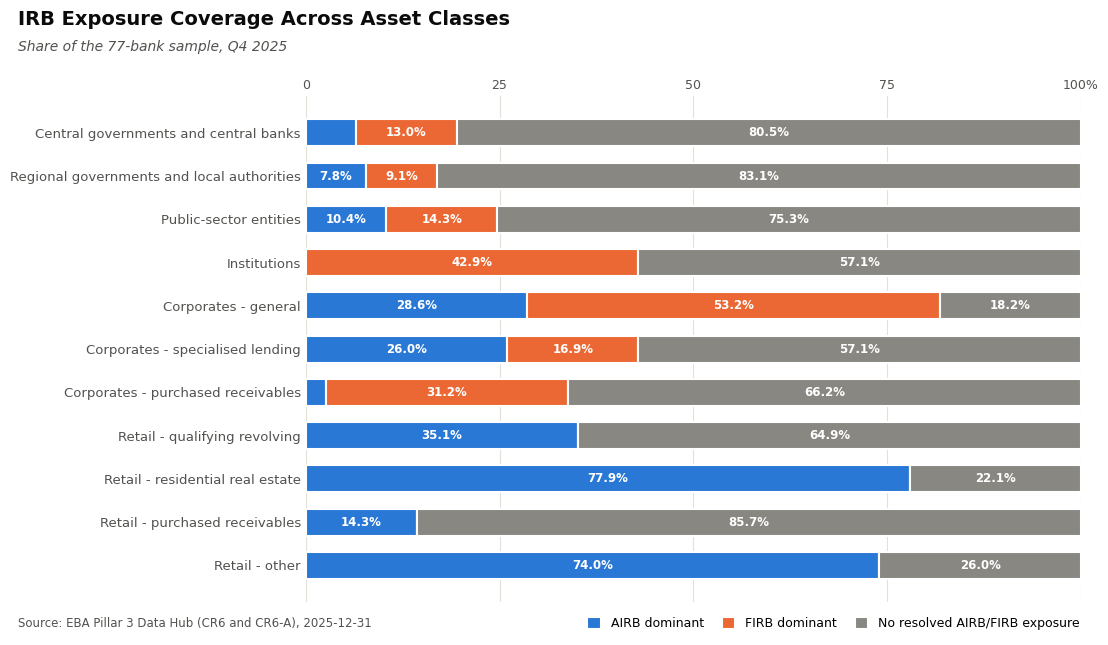

In [28]:
import matplotlib.pyplot as plt

# Two categorical hues for the two treatments; the third segment is an absence of evidence,
# so it takes a neutral rather than a third category colour.
AIRB_BLUE, FIRB_ORANGE, NEUTRAL = "#2a78d6", "#eb6834", "#898781"
INK, MUTED, GRID_LINE = "#0b0b0b", "#52514e", "#e1e0d9"
SEGMENTS = [
    ("AIRB dominant", AIRB_BLUE),
    ("FIRB dominant", FIRB_ORANGE),
    ("No resolved AIRB/FIRB exposure", NEUTRAL),
]

fig, ax = plt.subplots(figsize=(11, 6.4))
y = list(range(len(CHART_CLASSES)))
left = [0.0] * len(CHART_CLASSES)

for name, colour in SEGMENTS:
    values = shares[name].to_numpy()
    ax.barh(y, values, left=left, height=0.62, color=colour, label=name,
            edgecolor="white", linewidth=1.5)
    for yi, value, start in zip(y, values, left):
        if value >= 7:  # label only segments wide enough to hold the text
            ax.text(start + value / 2, yi, f"{value:.1f}%", ha="center", va="center",
                    color="white", fontsize=8.5, fontweight="bold")
    left = [a + b for a, b in zip(left, values)]

ax.set_yticks(y, CHART_CLASSES, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ["0", "25", "50", "75", "100%"], fontsize=9)
ax.xaxis.set_ticks_position("top")
ax.set_axisbelow(True)
ax.grid(axis="x", color=GRID_LINE, linewidth=0.8)
ax.tick_params(length=0, colors=MUTED)
for side in ax.spines.values():
    side.set_visible(False)

fig.tight_layout(rect=[0, 0.045, 1, 0.88], pad=0.4)
fig.text(0.012, 0.955, "IRB Exposure Coverage Across Asset Classes",
         fontsize=14, fontweight="bold", color=INK)
fig.text(0.012, 0.915, f"Share of the {len(population)}-bank sample, Q4 2025",
         fontsize=10, style="italic", color=MUTED)

FOOTER_Y = 0.02
fig.text(0.012, FOOTER_Y,
         f"Source: EBA Pillar 3 Data Hub (CR6 and CR6-A), {REFERENCE_DATE}",
         fontsize=8.5, color=MUTED, va="center")
fig.legend(*ax.get_legend_handles_labels(), loc="center right",
           bbox_to_anchor=(0.988, FOOTER_Y), bbox_transform=fig.transFigure,
           ncol=3, frameon=False, fontsize=9,
           handlelength=1.1, handleheight=1.1, columnspacing=1.4)
plt.show()

**Observations**

* **Retail is uniformly advanced.** Every resolved retail cell is AIRB dominant, and the FIRB
  count across all retail classes is zero. This is consistent with retail IRB requiring own LGD
  estimates, which leaves a foundation variant unavailable for these classes.
* **Institutions is the inverse.** Every resolved cell is FIRB dominant, and the AIRB count is
  zero.
* **Corporates - general is the most broadly covered non-retail class**, and it divides between
  both treatments.
* **The sovereign-like classes are largely unresolved.** Central governments, regional governments
  and public-sector entities carry a positive AIRB or FIRB subtotal for a small minority of the
  sample.

The neutral segment carries the greatest interpretive risk, since it records an absence of
resolved CR6 evidence rather than a finding about the approach in use. It is drawn as a neutral
for that reason.

**Reproducibility.** Figures reflect the Hub as published at execution time. Subsequent
resubmissions change which instance is current, so a rerun may move the numbers. `InstanceID` and
`Report File Link` are retained in the extracts to support audit against the source filings.